# Matrix-matrix multiplication python vs pytorch

In [17]:
import torch
import random

## 1) Genereate random data

In [21]:
random.seed(667)

b = 0
m_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
plain_times = [0 for _ in m_values]
torch_times = [0 for _ in m_values]

## 2) Python function

In [22]:
def matmulPlain(W, X, b,):
    rows, cols = len(W), len(X[0])
    outputs = [[0 for _ in range(cols)] for _ in range(rows)]
    for i in range(rows):
        for j in range(cols):
            for k in range(len(W[0])):
                outputs[i][j] += W[i][k] * X[k][j]
            outputs[i][j] += b
    return outputs

In [23]:
i = 0
for m in m_values: 
    W = [[random.random() for _ in range(m)] for _ in range(90)]
    X = [[random.random() for _ in range(110)] for _ in range(m)]
    result = %timeit -o matmulPlain(W, X, b)
    plain_times[i] = result.average
    i += 1

print(plain_times)



4.85 ms ± 44.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
8.51 ms ± 6.25 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
12.3 ms ± 109 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
16 ms ± 37.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
19.9 ms ± 234 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
23.6 ms ± 76.1 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
27.4 ms ± 180 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
31.2 ms ± 177 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
34.9 ms ± 37.4 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
39.5 ms ± 921 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
[0.004850987321426926, 0.00851029065718259, 0.012344398749971463, 0.0159968336914192, 0.01990915362997579, 0.023559427971070235, 0.02735587737136354, 0.031168356528879875, 0.03490341427116488, 0.03951566725674118]


## 3) Pytorch function

In [24]:
def matMulTorch(W, X, b):
    W_t = torch.tensor(W)
    X_t = torch.tensor(X)
    result = W_t.matmul(X_t)
    
    result += b
    return result

In [25]:
i = 0
for m in m_values:
    W = [[random.random() for _ in range(m)] for _ in range(90)]
    X = [[random.random() for _ in range(110)] for _ in range(m)]
    result2 = %timeit -o matMulTorch(W, X, b)
    torch_times[i] = result2.average
    i += 1
print(torch_times)

202 μs ± 1.68 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
367 μs ± 3.39 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
542 μs ± 13.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
712 μs ± 2.46 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
874 μs ± 5.45 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.04 ms ± 7.16 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.23 ms ± 16.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.38 ms ± 4.04 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.56 ms ± 15.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.72 ms ± 9.04 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
[0.00020151493394265086, 0.00036654654757044876, 0.0005415705594288219, 0.0007117232142876934, 0.0008737894347120475, 0.0010382498214291575, 0.0012268273929990495, 0.001384321643000086, 0.0015630831487152528, 0.0017152480354291452]


## 4) Speedup results


In [26]:
speedups = [plain/t for plain, t in zip(plain_times, torch_times)]
print(speedups)

[24.07259465349337, 23.217489602864003, 22.793703488961306, 22.47620053735236, 22.784841334842575, 22.69148280578612, 22.298065341115784, 22.515256253114824, 22.329851294125394, 23.037873497318763]


## 5) Graph

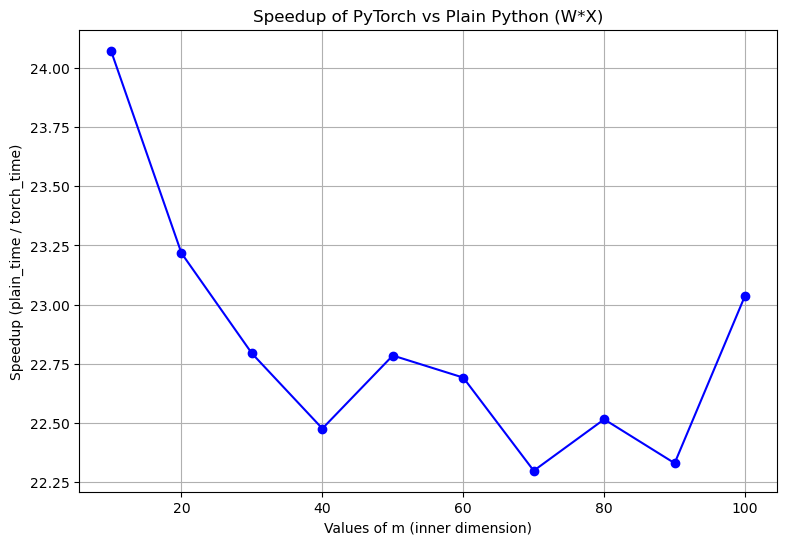

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
plt.plot(m_values, speedups, marker='o', linestyle='-', color='b')

plt.title("Speedup of PyTorch vs Plain Python (W*X)")
plt.xlabel("Values of m (inner dimension)")
plt.ylabel("Speedup (plain_time / torch_time)")

plt.grid(True)
plt.show()

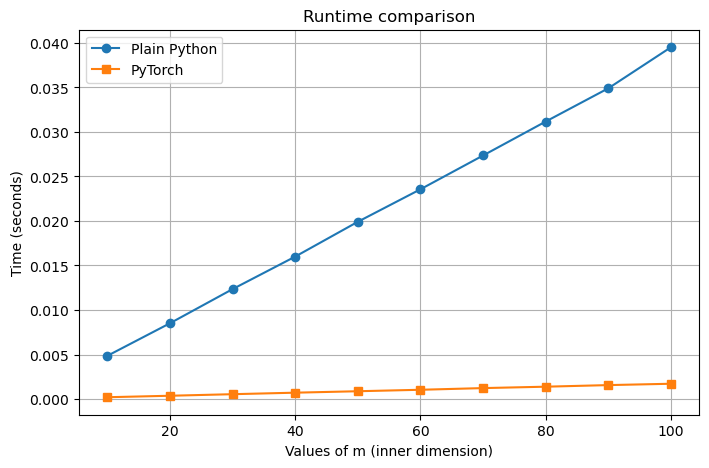

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(m_values, plain_times, marker='o', label="Plain Python")
plt.plot(m_values, torch_times, marker='s', label="PyTorch")
plt.title("Runtime comparison")
plt.xlabel("Values of m (inner dimension)")
plt.ylabel("Time (seconds)")
plt.legend()
plt.grid(True)
plt.show()